In [1]:
import json
from pathlib import Path

# must import pysr before torch because julia kernel init weirdness
from pysr import PySRRegressor

# torch AFTER pysr, dont let ruff/isort/whatever reorder this
import numpy as np

import sympy
import matplotlib.pyplot as plt
from jaxtyping import Float
from scipy.fft import fft2

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
# load activations for each prompt
def load_activations(
	model_name: str,
	base_path: Path = Path("../docs/demo"),
) -> tuple[
	list[dict],
	list[np.lib.npyio.NpzFile],
]:
	model_path: Path = base_path / model_name
	with open(model_path / "prompts.jsonl") as f:
		prompts = [json.loads(line) for line in f]

	activations = [
		np.load(model_path / "prompts" / p["hash"] / "activations.npz") for p in prompts
	]

	return prompts, activations


PROMPTS, ACTIVATIONS = load_activations("pythia-14m")

In [3]:
ACTIVATIONS[0]

NpzFile '..\\docs\\demo\\pythia-14m\\prompts\\0FXa04qYJZZbhploNh7DVA\\activations.npz' with keys: blocks.0.attn.hook_pattern, blocks.1.attn.hook_pattern, blocks.2.attn.hook_pattern, blocks.3.attn.hook_pattern, blocks.4.attn.hook_pattern...

In [4]:
for i in range(5):
	print(PROMPTS[i]["text"])
	print("=" * 50)

rent types of very small pasta – barely something to start when talking about the evolution of Pasta.

Pastas used in the game. Unfortunately, the macs where never used

Which is one of the saddest things about the project, really. It had the framework and
he problem I realized when doing some tests is that people never look at the bill! They think it’s some kind of prop, so they never actually read its details.

Plus, if you’re zoomed out too much, you can’t actually read it, so it’s hard to know what’s goi
ns through several seemingly random mutations over time, with the most apt permutation surviving. This genetic car simulator is, in my opinion, a great example of actual evolution of a species facing a challenge. But is it a game?

In a game, you need to c
Topic: reinvent midnight madness

Amazon announced a new service at the AWS re:Invent Midnight Madness event. Amazon Sumerian is a solution that aims to make it easier for developers to build virtual reality, augmented reality, a

In [5]:
ACTIVATIONS[1]["blocks.4.attn.hook_pattern"][0, 0].shape

(70, 70)

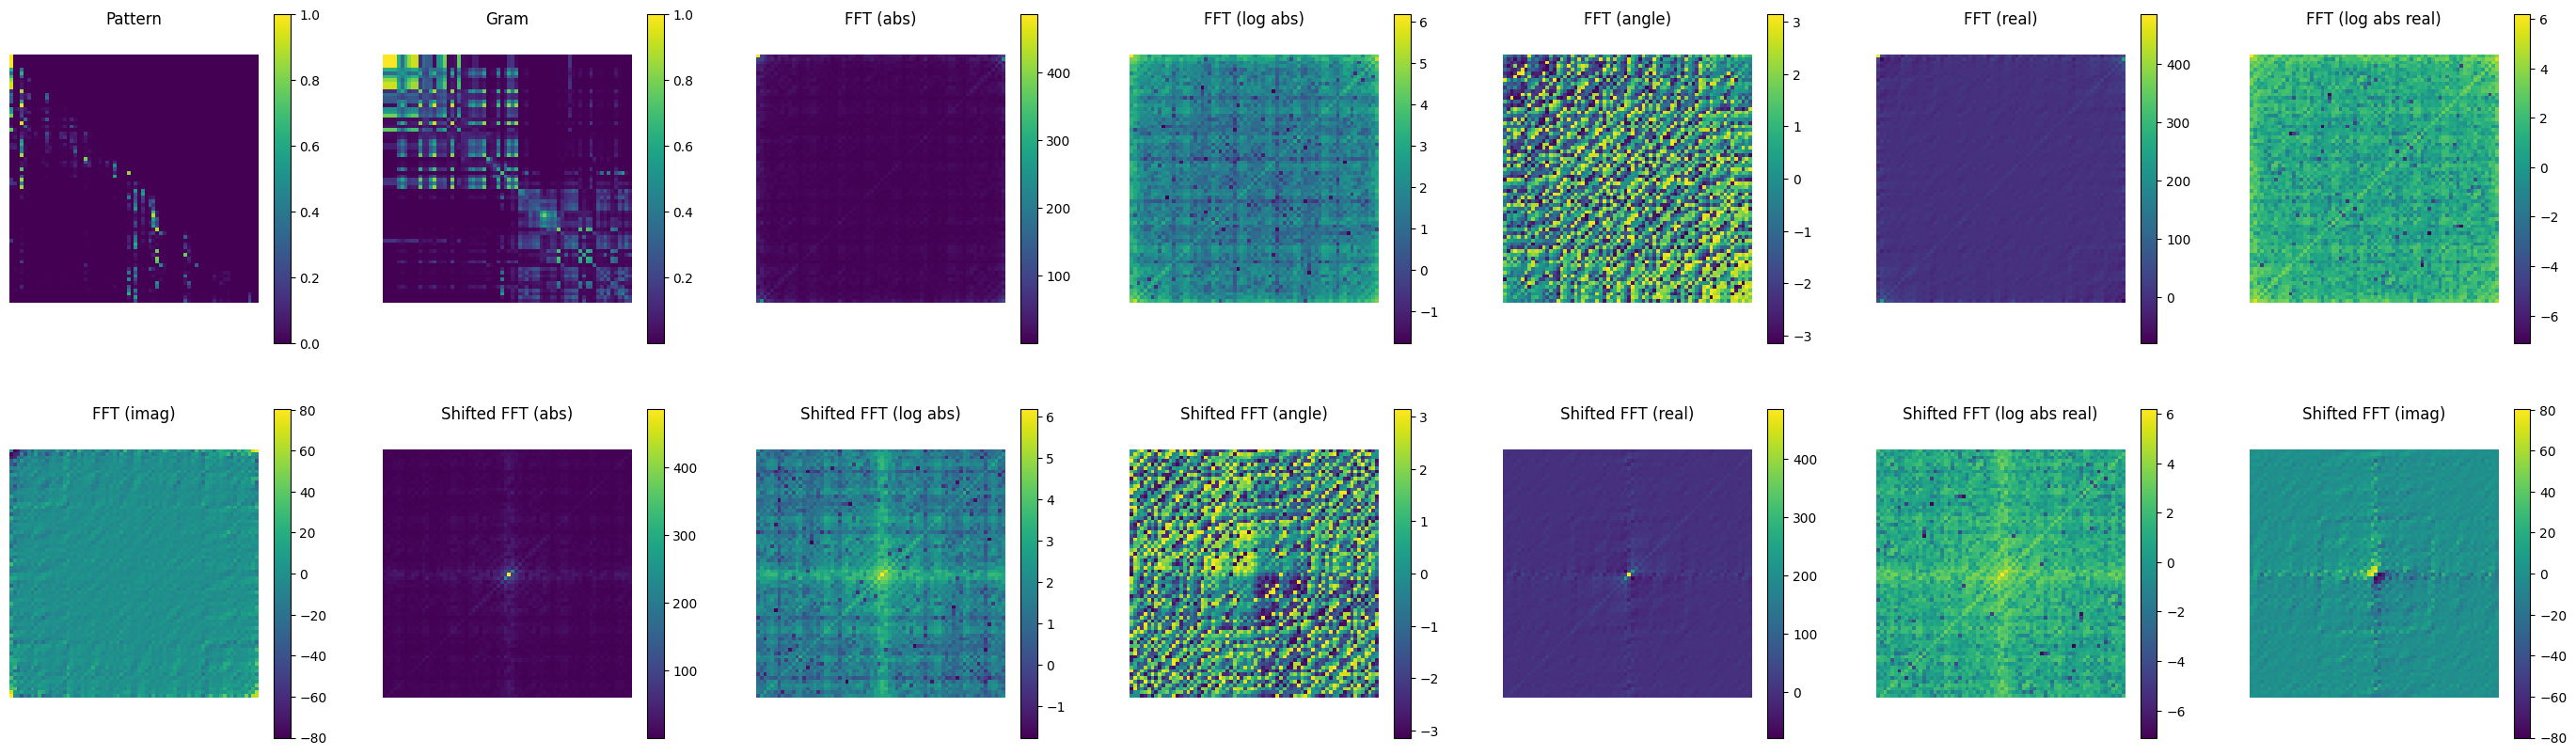

(<Figure size 3500x1000 with 28 Axes>,
 array([[<Axes: title={'center': 'Pattern'}>,
         <Axes: title={'center': 'Gram'}>,
         <Axes: title={'center': 'FFT (abs)'}>,
         <Axes: title={'center': 'FFT (log abs)'}>,
         <Axes: title={'center': 'FFT (angle)'}>,
         <Axes: title={'center': 'FFT (real)'}>,
         <Axes: title={'center': 'FFT (log abs real)'}>],
        [<Axes: title={'center': 'FFT (imag)'}>,
         <Axes: title={'center': 'Shifted FFT (abs)'}>,
         <Axes: title={'center': 'Shifted FFT (log abs)'}>,
         <Axes: title={'center': 'Shifted FFT (angle)'}>,
         <Axes: title={'center': 'Shifted FFT (real)'}>,
         <Axes: title={'center': 'Shifted FFT (log abs real)'}>,
         <Axes: title={'center': 'Shifted FFT (imag)'}>]], dtype=object))

In [6]:
def plot_pattern_info(
	pattern: Float[np.ndarray, "n_ctx n_ctx"],
	show: bool = True,
) -> tuple[plt.Figure, plt.Axes]:
	gram = pattern @ pattern.T
	fft = fft2(gram)
	fft_shifted = np.fft.fftshift(fft)
	data: dict = {
		"Pattern": pattern,
		"Gram": gram,
		"FFT (abs)": np.abs(fft),
		"FFT (log abs)": np.log(np.abs(fft)),
		"FFT (angle)": np.angle(fft),
		"FFT (real)": np.real(fft),
		"FFT (log abs real)": np.log(np.abs(np.real(fft))),
		"FFT (imag)": np.imag(fft),
		"Shifted FFT (abs)": np.abs(fft_shifted),
		"Shifted FFT (log abs)": np.log(np.abs(fft_shifted)),
		"Shifted FFT (angle)": np.angle(fft_shifted),
		"Shifted FFT (real)": np.real(fft_shifted),
		"Shifted FFT (log abs real)": np.log(np.abs(np.real(fft_shifted))),
		"Shifted FFT (imag)": np.imag(fft_shifted),
	}

	# Create subplots and add colorbars using a loop
	n_data: int = len(data)
	n_cols: int = round(n_data / 2)
	fig, axs = plt.subplots(2, n_cols, figsize=(5 * n_cols, 10))
	for ax, (title, datum) in zip(axs.flat[:n_data], data.items()):
		cax = ax.matshow(datum)
		fig.colorbar(cax, ax=ax)
		ax.set_title(title)
		ax.axis("off")

	if show:
		plt.show()

	return fig, axs


def get_single_attn_pattern(
	sample: int,
	layer: int,
	head: int,
	activations=ACTIVATIONS,
) -> Float[np.ndarray, "n_ctx n_ctx"]:
	return activations[sample][f"blocks.{layer}.attn.hook_pattern"][0, head]


plot_pattern_info(get_single_attn_pattern(1, 4, 0))

In [7]:
# set up matrix
pattern = get_single_attn_pattern(1, 4, 0)
gram = pattern @ pattern.T
fft = np.fft.fft2(gram)
fft_shifted = np.fft.fftshift(fft)
log_fft = np.log(np.abs(fft_shifted) + 1e-8)  # Add epsilon to prevent log(0)
matrix = log_fft

# set up pysr
model = PySRRegressor(
	# Search parameters
	niterations=500,
	maxsize=25,
	populations=10,
	population_size=50,
	# Lots of potentially useful operators
	binary_operators=[
		"+",
		"*",
		"-",
		"/",
		"^",
		"abs2(x,y) = x^2 + y^2",  # Radial distance squared
		"hypot(x,y) = sqrt(x^2 + y^2)",  # Radial distance
		# "atan2",  # Angular coordinate
	],
	unary_operators=[
		# Basic functions
		"exp",
		"log1p",
		"abs",
		"sin",
		"cos",
		"tan",
		"sinh",
		"cosh",
		"tanh",
		# Squared terms
		"square(x) = x^2",
		"cube(x) = x^3",
		# Gaussian-like functions
		"gauss(x) = exp(-x^2)",
		"invexp(x) = exp(-abs(x))",
		# Rotated coordinates (various angles)
		# "rot45x(x,y) = x * cos(pi/4) + y * sin(pi/4)",
		# "rot45y(x,y) = -x * sin(pi/4) + y * cos(pi/4)",
		# "rot30x(x,y) = x * cos(pi/6) + y * sin(pi/6)",
		# "rot30y(x,y) = -x * sin(pi/6) + y * cos(pi/6)",
		# "rot60x(x,y) = x * cos(pi/3) + y * sin(pi/3)",
		# "rot60y(x,y) = -x * sin(pi/3) + y * cos(pi/3)",
	],
	# Use batching for speed
	batching=True,
	batch_size=1000,
	# Loss function
	elementwise_loss="loss(prediction, target) = (prediction - target)^2",
	# Define SymPy mappings
	extra_sympy_mappings={
		"square": lambda x: x**2,
		"cube": lambda x: x**3,
		"gauss": lambda x: sympy.exp(-(x**2)),
		"invexp": lambda x: sympy.exp(-abs(x)),
		"abs2": lambda x, y: x**2 + y**2,
		"hypot": lambda x, y: sympy.sqrt(x**2 + y**2),
		# "rot45x": lambda x, y: x * sympy.cos(sympy.pi/4) + y * sympy.sin(sympy.pi/4),
		# "rot45y": lambda x, y: -x * sympy.sin(sympy.pi/4) + y * sympy.cos(sympy.pi/4),
		# "rot30x": lambda x, y: x * sympy.cos(sympy.pi/6) + y * sympy.sin(sympy.pi/6),
		# "rot30y": lambda x, y: -x * sympy.sin(sympy.pi/6) + y * sympy.cos(sympy.pi/6),
		# "rot60x": lambda x, y: x * sympy.cos(sympy.pi/3) + y * sympy.sin(sympy.pi/3),
		# "rot60y": lambda x, y: -x * sympy.sin(sympy.pi/3) + y * sympy.cos(sympy.pi/3),
	},
	# Prevent too much nesting of expensive functions
	nested_constraints={
		"exp": {"exp": 0},
		"gauss": {"gauss": 0},
		"invexp": {"invexp": 0},
	},
	# Other parameters
	parsimony=0.0001,  # Very small to allow complex expressions initially
	turbo=True,  # Speed up evaluation
)
# This will set up the model for 40 iterations of the search code, which contains hundreds of thousands of mutations and equation evaluations.

# Let's train this model on our dataset:
X = np.indices(matrix.shape).reshape(2, -1).T
y = matrix.ravel()
model.fit(X, y)

f:\projects\attention-motifs\.venv\Lib\site-packages\pysr\sr.py:2766: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
f:\projects\attention-motifs\.venv\Lib\site-packages\pysr\sr.py:84: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(


Compiling Julia backend...


[ Info: Started!



Expressions evaluated per second: 1.830e+04
Progress: 137 / 5000 total iterations (2.740%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.684e-01  1.594e+01  y = 1.6961
4           7.639e-01  1.946e-03  y = cosh(x₀ ^ 0.036544)
6           7.539e-01  6.607e-03  y = hypot(tanh(x₀ * 0.080159), 1.4733)
7           7.416e-01  1.648e-02  y = sinh(cosh(cos(cos(cos(log1p(x₁))))))
9           7.177e-01  1.640e-02  y = sinh(cosh(cos(cos(log1p(x₀ * log1p(x₀))))))
11          6.918e-01  1.835e-02  y = cosh(sinh(cos(cos(log1p(x₀ * log1p(x₀)))))) ^ 1.2713
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop exec

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                          1.6961485   
	1         1.946439e-03                              cosh(x0 ^ 0.03652446)   
	2         2.208220e-02                   hypot(1.5099051, cos(log1p(x1)))   
	3         1.183961e-01                   exp(invexp(cos(x0 / 22.204002)))   
	4         8.040190e-03             2.573451 ^ invexp(cos(x1 / 22.267317))   
	5         8.666681e-03     exp(invexp(cos(0.5517173 - (x0 / 16.489872))))   
	6         9.059530e-03  cosh(hypot(0.84965616, tan(invexp(cos(x0 / 22....   
	7         4.604226e-03  (abs2(-0.03492774, cos(x1 / 22.267317)) ^ -0.1...   
	8         3.220540e-02  cosh(hypot(cos(log1p(x1)), tan(invexp(cos(x0 /...   
	9   >>>>  1.272378e-01  cosh(invexp(cos(x0 / 22.267317)) + invexp(cos(...   
	10        1.668939e-02  square(cosh(hypot(invexp(cos(x1 / 22.267317)),...   
	11        5.681469e-03  cosh(tan(invexp(cos(x1 / 22.352499)))) * cosh(...   
	12        9.077585e-04  cosh(sinh(sinh(invexp(cos(x1 / 22.408623))))) ...   
	13        2.458446e-03  sinh(cosh(invexp(cos(x1 / 22.310844) * 2.25341...   
	14        5.345382e-05  sinh(cosh(0.08666036 + invexp(cos(x1 / 22.3108...   
	15        3.080287e-06  sinh(cosh(invexp(cos(x1 / 22.310844) * 2.25341...   
	16        7.652911e-08  sinh(cosh(invexp(cos(x1 / 22.310844) * 2.25341...   
	
	        loss  complexity  
	0   0.768402           1  
	1   0.763929           4  
	2   0.747244           5  
	3   0.663810           6  
	4   0.658494           7  
	5   0.652812           8  
	6   0.646924           9  
	7   0.643953          10  
	8   0.623544          11  
	9   0.549046          12  
	10  0.531022          14  
	11  0.528013          15  
	12  0.526578          18  
	13  0.522708          21  
	14  0.522680          22  
	15  0.522677          24  
	16  0.522677          25  
]

In [8]:
model.equations_

,complexity,loss,equation,score,sympy_format,lambda_format
0,1,0.768402,1.6961485,0.000000e+00,1.69614850000000,PySRFunction(X=>1.69614850000000)
1,4,0.763929,cosh(x0 ^ 0.03652446),1.946439e-03,cosh(x0**0.03652446),PySRFunction(X=>cosh(x0**0.03652446))
2,5,0.747244,"hypot(1.5099051, cos(log1p(x1)))",2.208220e-02,1.5099051*sqrt(0.438632387708752*cos(log(x1 + ...,PySRFunction(X=>1.5099051*sqrt(0.4386323877087...
3,6,0.663810,exp(invexp(cos(x0 / 22.204002))),1.183961e-01,exp(exp(-Abs(cos(x0/22.204002)))),PySRFunction(X=>exp(exp(-Abs(cos(x0/22.204002)...
4,7,0.658494,2.573451 ^ invexp(cos(x1 / 22.267317)),8.040190e-03,2.573451**exp(-Abs(cos(x1/22.267317))),PySRFunction(X=>2.573451**exp(-Abs(cos(x1/22.2...
5,8,0.652812,exp(invexp(cos(0.5517173 - (x0 / 16.489872)))),8.666681e-03,exp(exp(-Abs(cos(0.5517173 - x0/16.489872)))),PySRFunction(X=>exp(exp(-Abs(cos(0.5517173 - x...
6,9,0.646924,"cosh(hypot(0.84965616, tan(invexp(cos(x0 / 22....",9.059530e-03,cosh(sqrt(tan(exp(-Abs(cos(x0/22.249384))))**2...,PySRFunction(X=>cosh(sqrt(tan(exp(-Abs(cos(x0/...
7,10,0.643953,"(abs2(-0.03492774, cos(x1 / 22.267317)) ^ -0.1...",4.604226e-03,(cos(x1/22.267317)**2 + 0.0012199470215076)**(...,PySRFunction(X=>(cos(x1/22.267317)**2 + 0.0012...
8,11,0.623544,"cosh(hypot(cos(log1p(x1)), tan(invexp(cos(x0 /...",3.220540e-02,cosh(sqrt(cos(log(x1 + 1))**2 + tan(exp(-Abs(c...,PySRFunction(X=>cosh(sqrt(cos(log(x1 + 1))**2 ...
9,12,0.549046,cosh(invexp(cos(x0 / 22.267317)) + invexp(cos(...,1.272378e-01,cosh(exp(-Abs(cos(x1/22.267317))) + exp(-Abs(c...,PySRFunction(X=>cosh(exp(-Abs(cos(x1/22.267317...


In [9]:
idxs = np.indices(matrix.shape).reshape(2, -1).T
idxs.shape

(4900, 2)

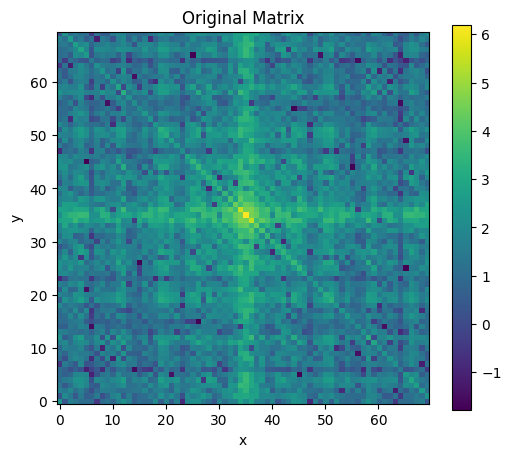

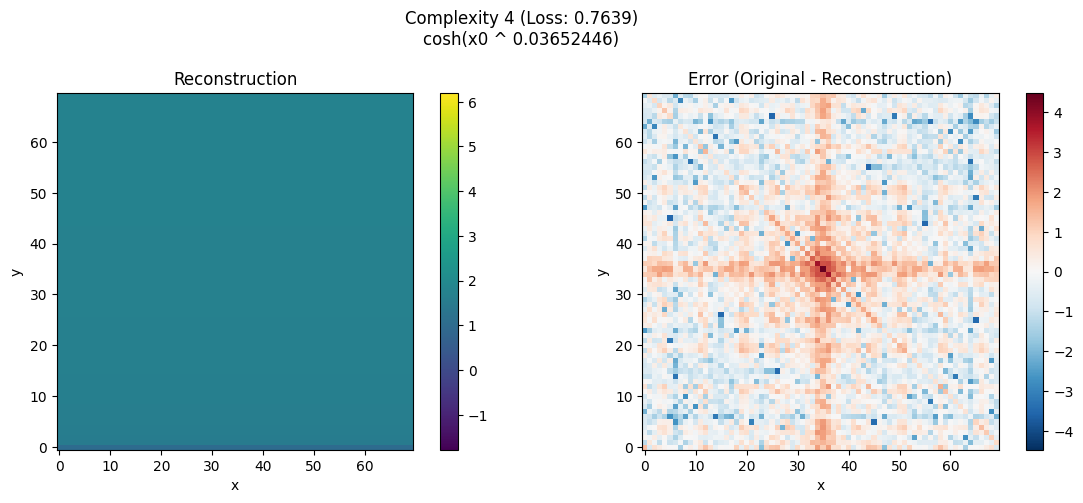

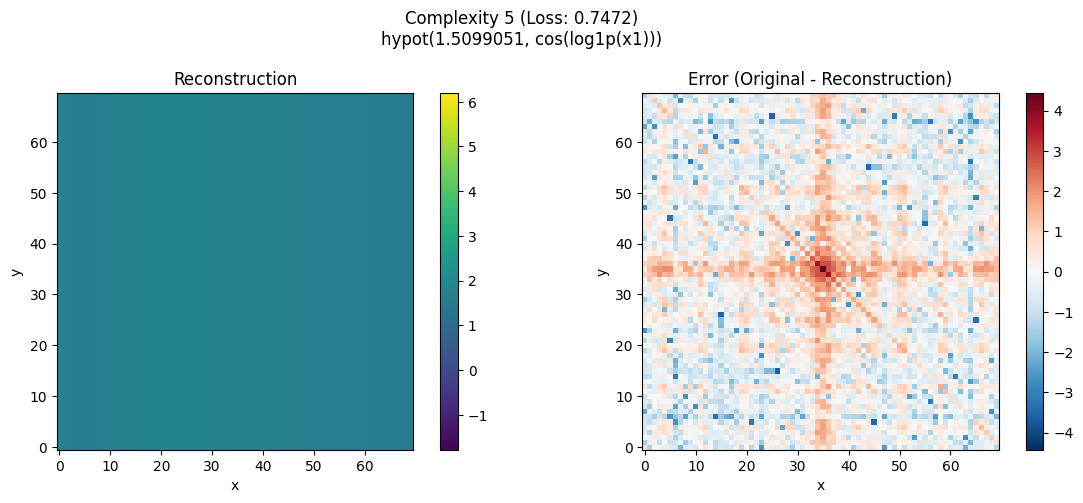

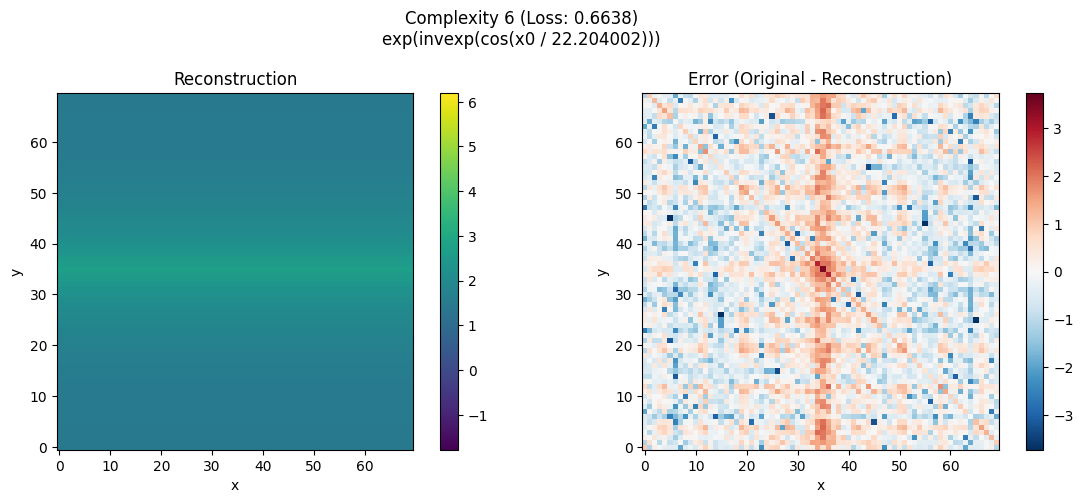

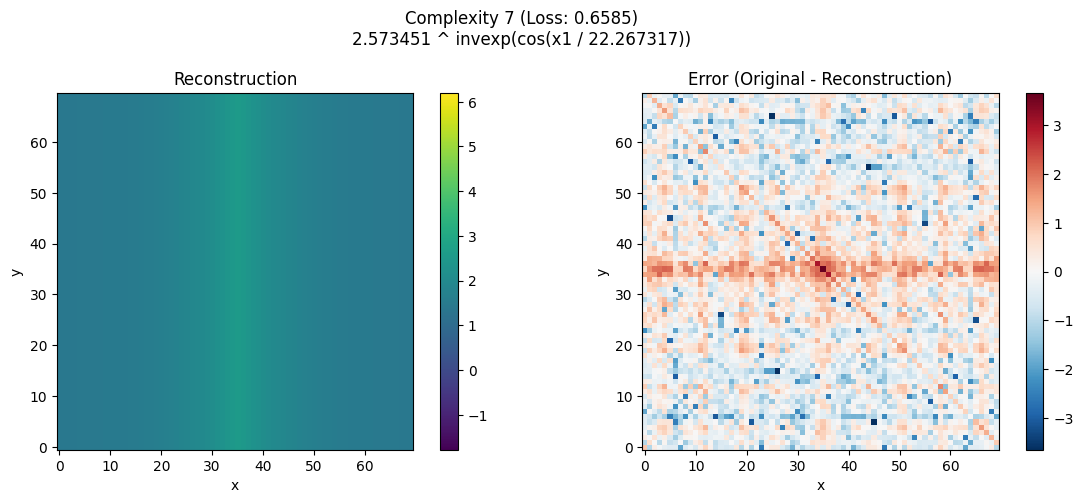

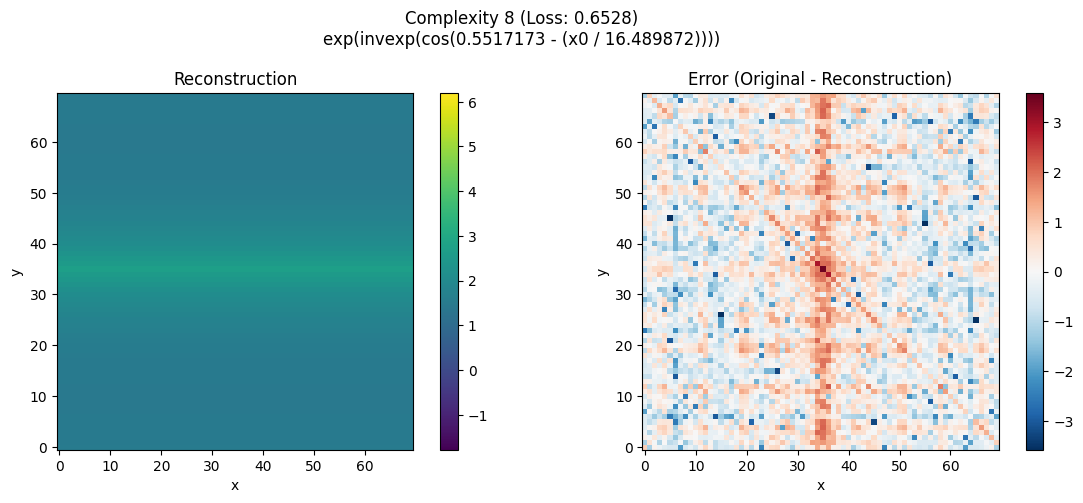

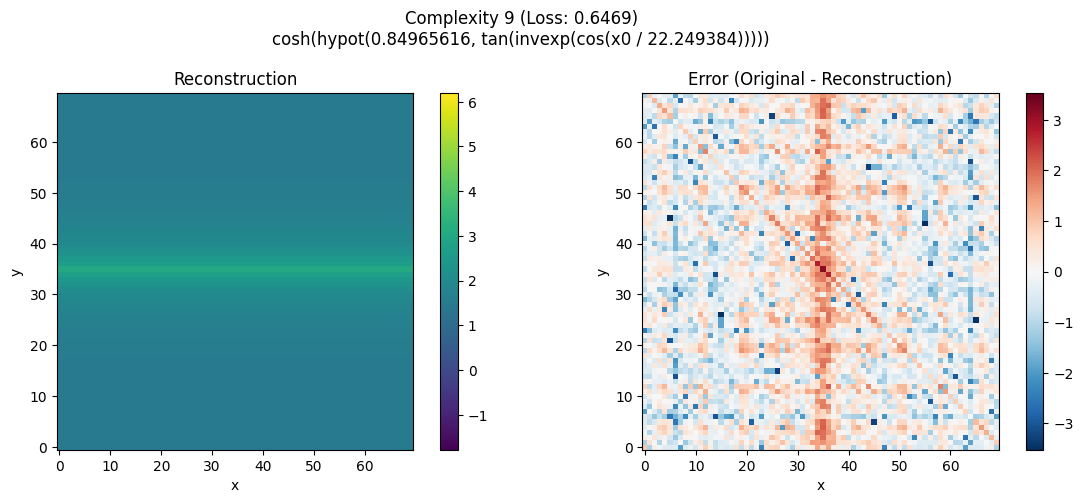

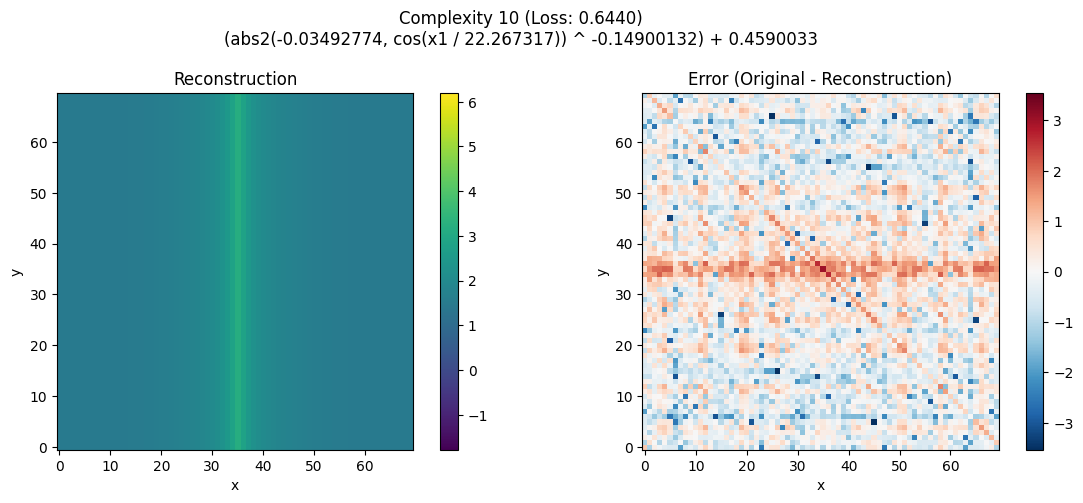

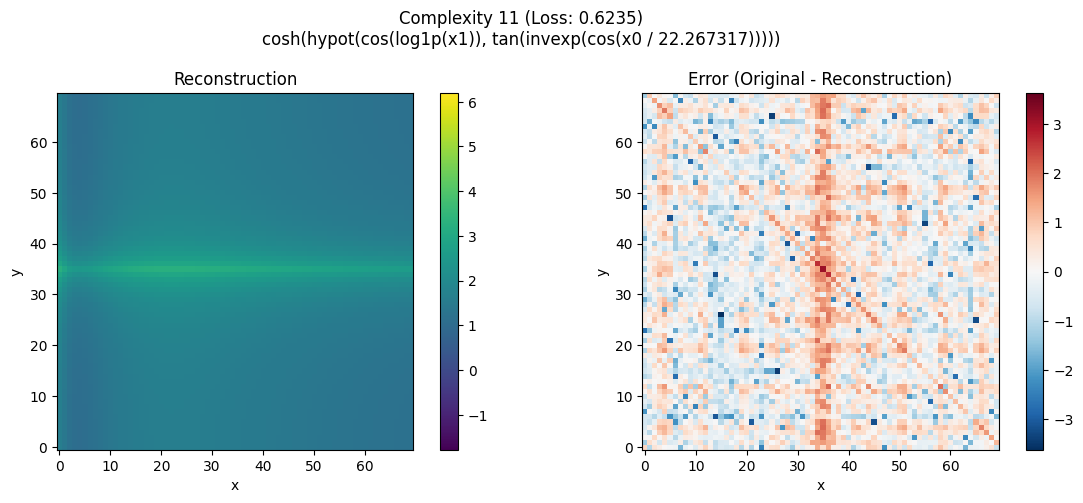

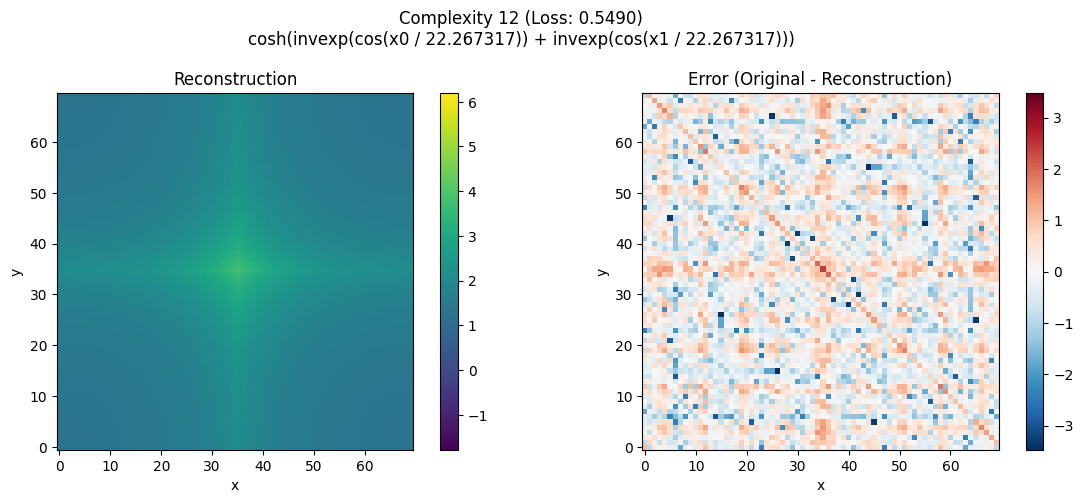

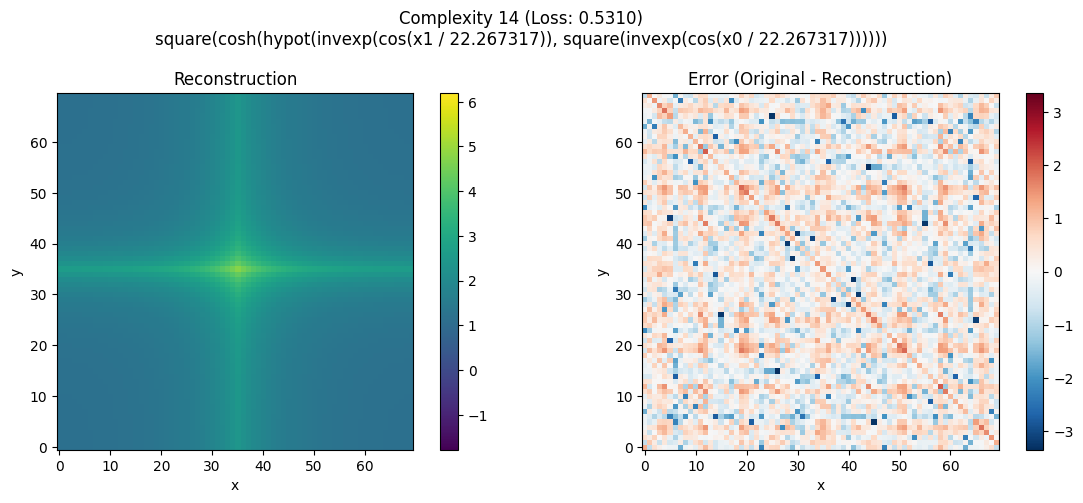

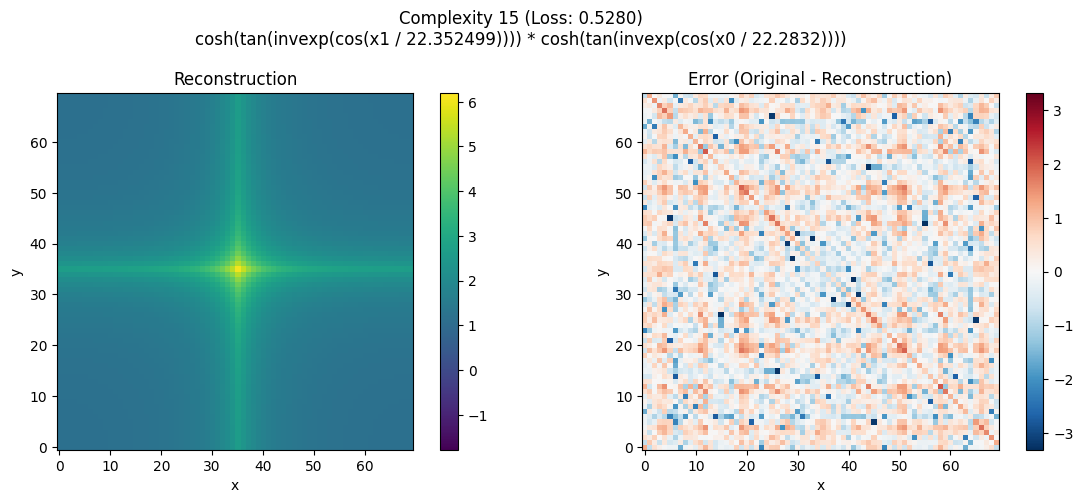

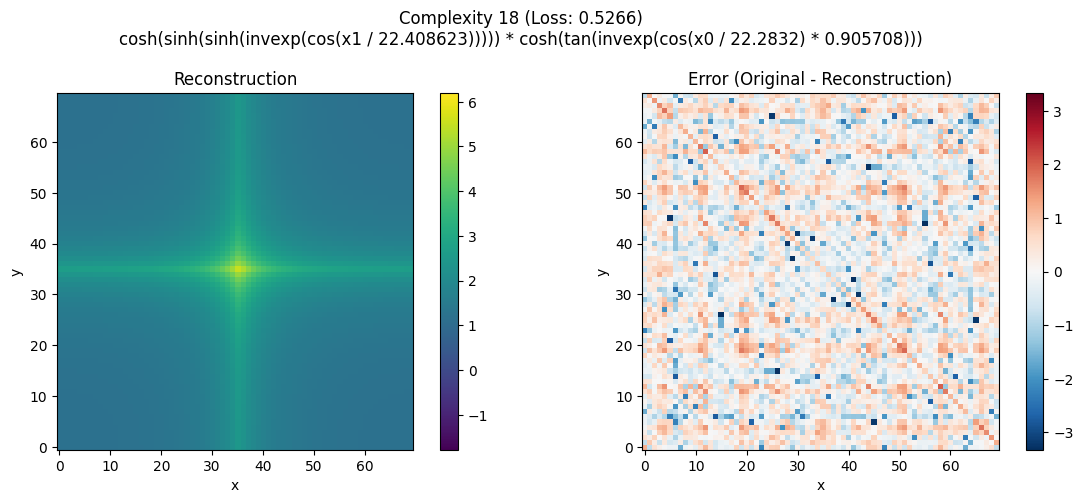

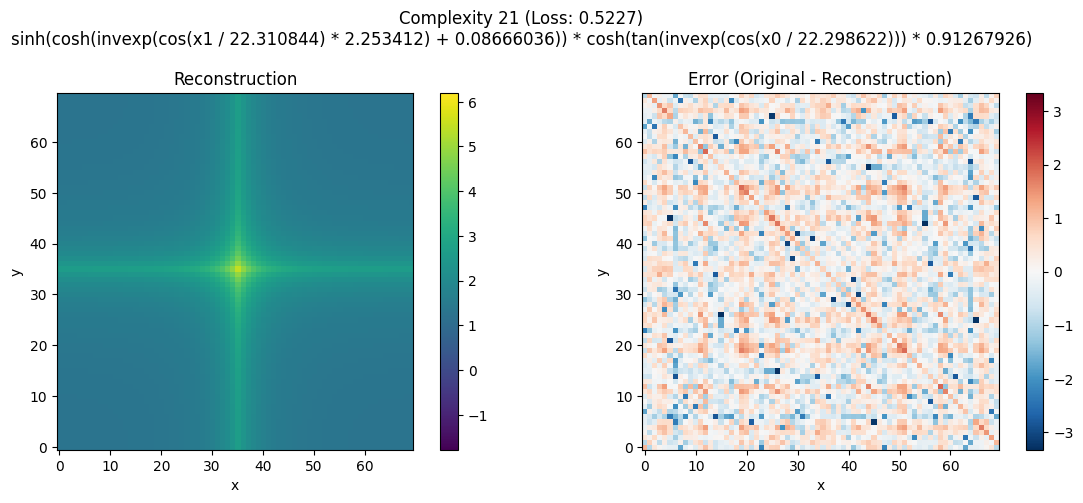

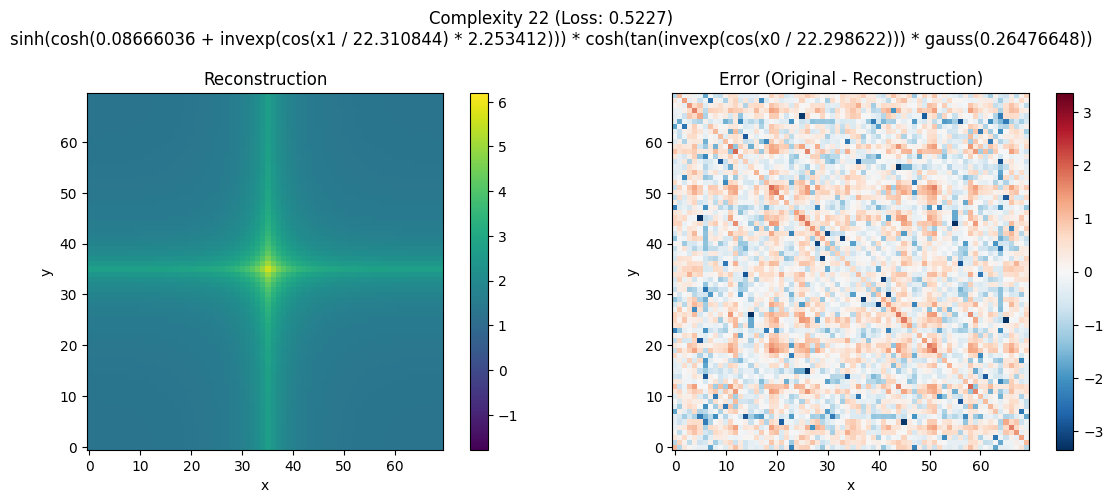

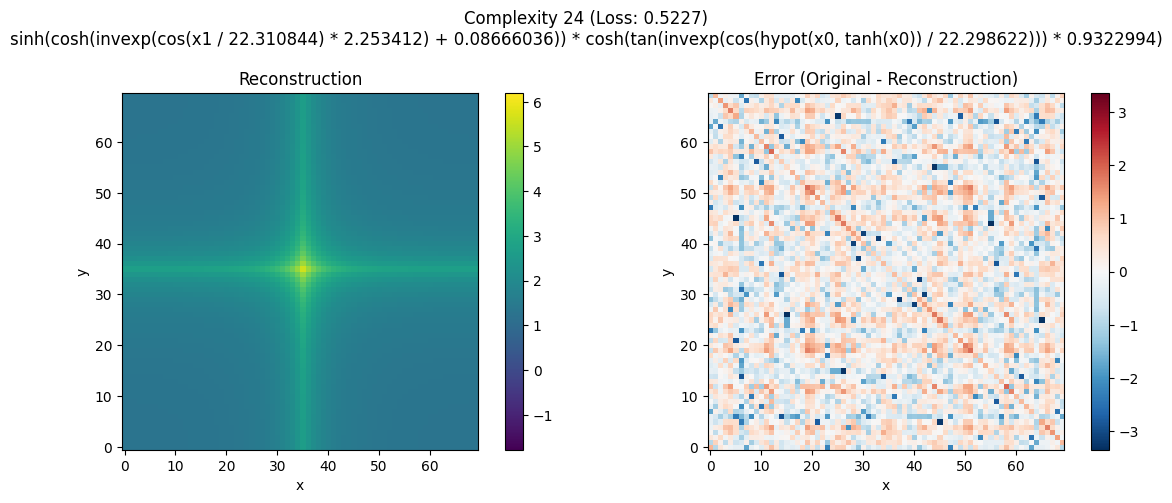

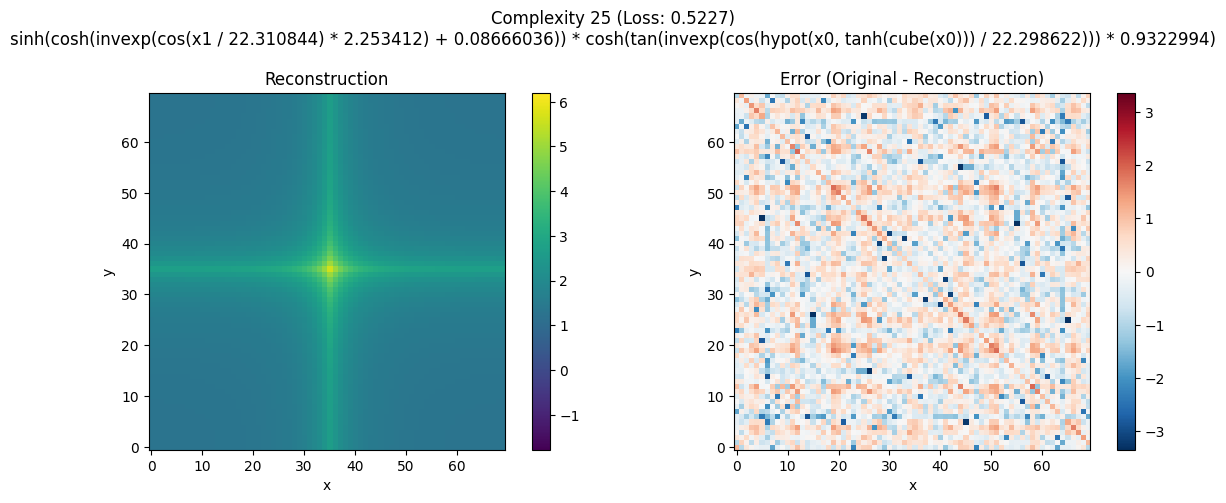

In [10]:
def plot_reconstructions(
	original_matrix: np.ndarray, model_equations, start_complexity: int = 2
) -> None:
	"""
	Plot original matrix and reconstructions at each complexity level.

	Args:
	    original_matrix: The original matrix being approximated
	    model_equations: DataFrame containing the PySR equations
	    start_complexity: Minimum complexity to start showing (default 2)
	"""
	# Generate frequency coordinates
	N = original_matrix.shape[0]
	# freqs = np.fft.fftshift(np.fft.fftfreq(N))

	# First, show the original matrix
	plt.figure(figsize=(6, 5))
	plt.imshow(original_matrix, origin="lower")
	plt.colorbar()
	plt.title("Original Matrix")
	plt.xlabel("x")
	plt.ylabel("y")
	plt.show()

	# Get unique complexity levels
	complexities = sorted(model_equations["complexity"].unique())
	complexities = [c for c in complexities if c >= start_complexity]

	# Create coordinate grid
	y, x = np.meshgrid(range(N), range(N))
	coords = np.stack([x.ravel(), y.ravel()], axis=1)

	# For each complexity level
	for complexity in complexities:
		# Get the best equation at this complexity level
		eq_row = model_equations[model_equations["complexity"] == complexity].iloc[-1]
		eq = eq_row["lambda_format"]

		try:
			# Generate prediction
			y_pred = eq(coords)
			reconstructed = y_pred.reshape(original_matrix.shape)

			# Calculate difference
			difference = original_matrix - reconstructed

			# Create comparison plot
			fig, axes = plt.subplots(1, 2, figsize=(12, 5))
			fig.suptitle(
				f'Complexity {complexity} (Loss: {eq_row["loss"]:.4f})\n{eq_row["equation"]}'
			)

			# Reconstructed matrix
			vmin = min(original_matrix.min(), reconstructed.min())
			vmax = max(original_matrix.max(), reconstructed.max())

			im0 = axes[0].imshow(reconstructed, origin="lower", vmin=vmin, vmax=vmax)
			axes[0].set_title("Reconstruction")
			axes[0].set_xlabel("x")
			axes[0].set_ylabel("y")
			fig.colorbar(im0, ax=axes[0])

			# Difference plot
			diff_vmax = max(abs(difference.min()), abs(difference.max()))
			im1 = axes[1].imshow(
				difference,
				origin="lower",
				cmap="RdBu_r",
				vmin=-diff_vmax,
				vmax=diff_vmax,
			)
			axes[1].set_title("Error (Original - Reconstruction)")
			axes[1].set_xlabel("x")
			axes[1].set_ylabel("y")
			fig.colorbar(im1, ax=axes[1])

			plt.tight_layout(rect=[0, 0.03, 1, 0.95])
			plt.show()

		except Exception as e:
			print(f"Error plotting complexity {complexity}: {str(e)}")


# Example usage:
plot_reconstructions(matrix, model.equations_)